In [53]:
import csv
import pandas as pd

In [ ]:
# Windows-on (?) 
# params = {
#     'fileLocation': 'database\\winemag-data-130k-v2_clean.csv',
# }

In [55]:
#Nobara rendszeren
params = {
    'fileLocation': '/home/miso/Programming/Adattudomany/Adattudomany-Projektmunka/database/winemag-data-130k-v2_clean.csv',
}

## Adatok előfeldolgozása

In [56]:
df = csv.reader(open(params['fileLocation'], 'r', encoding='utf-8'))
columns = next(df)
columns[0] = 'id'  # Az első oszlop neve 'id' legyen
df = pd.DataFrame(df, columns=columns)

print(df.shape)
display(df.head())

(129971, 7)


,id,country,description,points,province,region_1,region_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley


In [57]:
df_categorized = df[['id', 'country', 'description', 'points', 'province', 'region_1', 'region_2']].copy()

# Konvertálás int-re
df_categorized['points'] = df_categorized['points'].astype(int)

# Min-Max skálázás (0-1 közé)
# Képlet: (x - min) / (max - min)
p_min = df_categorized['points'].min()
p_max = df_categorized['points'].max()
df_categorized['points_scaled'] = (df_categorized['points'] - p_min) / (p_max - p_min)

df_categorized['group'] = pd.qcut(df_categorized['points'],
                                 q=4,
                                 labels=['poor', 'below_avg', 'above_avg', 'excellent'])

# display(df_categorized['group'].value_counts())
display(df_categorized.head(5))

,id,country,description,points,province,region_1,region_2,points_scaled,group
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,,0.35,below_avg
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,,0.35,below_avg
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley,0.35,below_avg
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,,0.35,below_avg
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley,0.35,below_avg


## Adatok megismerése

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Alapvető statisztikák
print(f"Adatbázis mérete: {df.shape}")
print("\nHiányzó adatok száma:")
print(df.isnull().sum())

Adatbázis mérete: (129971, 7)

Hiányzó adatok száma:
id             0
country        0
description    0
points         0
province       0
region_1       0
region_2       0
dtype: int64


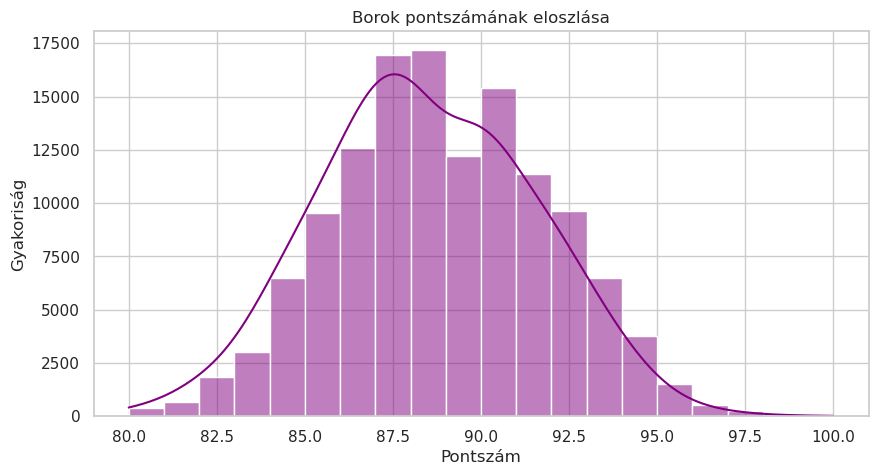

Átlagos pontszám: 88.45
Leggyakoribb pontszám: 88


In [ ]:
# Pontszámok eloszlása
plt.figure(figsize=(10, 5))
sns.histplot(df['points'].astype(int), bins=20, kde=True, color='purple', kde_kws={'bw_adjust': 3})
plt.title('Borok pontszámának eloszlása')
plt.xlabel('Pontszám')
plt.ylabel('Gyakoriság')
plt.show()

print(f"Átlagos pontszám: {df['points'].astype(int).mean():.2f}")
print(f"Leggyakoribb pontszám: {df['points'].astype(int).mode()[0]}")

Összesen 44 különböző ország található.


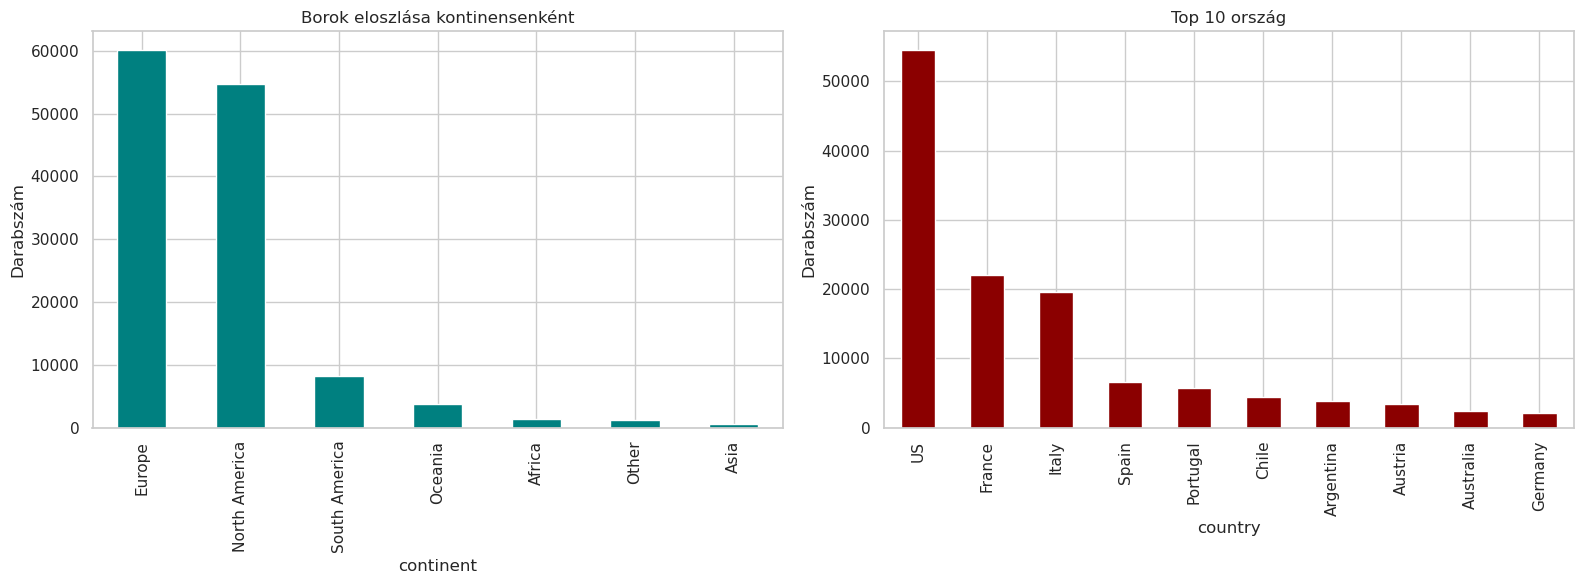

In [ ]:
# Országok és Kontinensek
continent_map = {
    'US': 'North America', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe', 
    'Portugal': 'Europe', 'Chile': 'South America', 'Argentina': 'South America', 
    'Australia': 'Oceania', 'Austria': 'Europe', 'Germany': 'Europe', 
    'New Zealand': 'Oceania', 'South Africa': 'Africa', 'Israel': 'Asia', 
    'Greece': 'Europe', 'Canada': 'North America', 'Hungary': 'Europe'
}

# Új oszlop a vizualizációhoz (ahol nincs megadva, ott 'Other')
df['continent'] = df['country'].map(continent_map).fillna('Other')

print(f"Összesen {df['country'].nunique()} különböző ország található.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kontinensek
df['continent'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Borok eloszlása kontinensenként')
axes[0].set_ylabel('Darabszám')

# Top 10 Ország
df['country'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='darkred')
axes[1].set_title('Top 10 ország')
axes[1].set_ylabel('Darabszám')

plt.tight_layout()
plt.show()

Különböző tartományok (Province) száma: 426


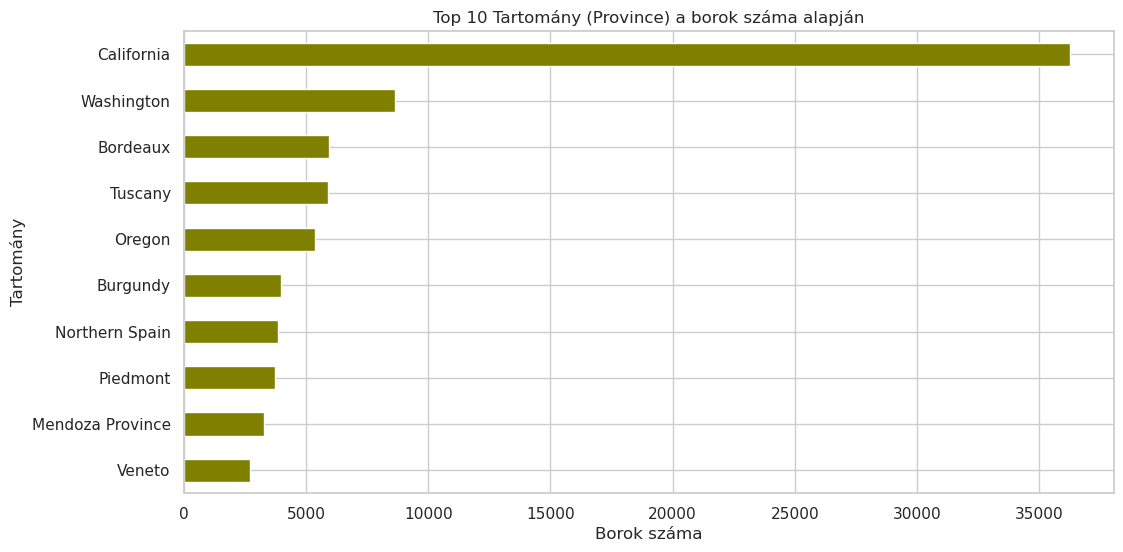

In [ ]:
# Régiók és Tartományok eloszlása
print(f"Különböző tartományok (Province) száma: {df['province'].nunique()}")

# Top 10 Tartomány
plt.figure(figsize=(12, 6))
df['province'].value_counts().head(10).plot(kind='barh', color='olive')
plt.title('Top 10 Tartomány (Province) a borok száma alapján')
plt.xlabel('Borok száma')
plt.ylabel('Tartomány')
plt.gca().invert_yaxis()
plt.show()

Összefüggés keresése

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beállítások a szebb grafikonokért
sns.set_theme(style="whitegrid")

df_categorized['points'] = df_categorized['points'].astype(int)

# Országok szerinti átlagos pontszám vizsgálata
# Csak azok az országok, ahol van elég adat (pl. több  mint 100 értékelés), hogy elkerüljük a torzítást
country_counts = df_categorized['country'].value_counts()
valid_countries = country_counts[country_counts > 100].index
df_filtered_country = df_categorized[df_categorized['country'].isin(valid_countries)]

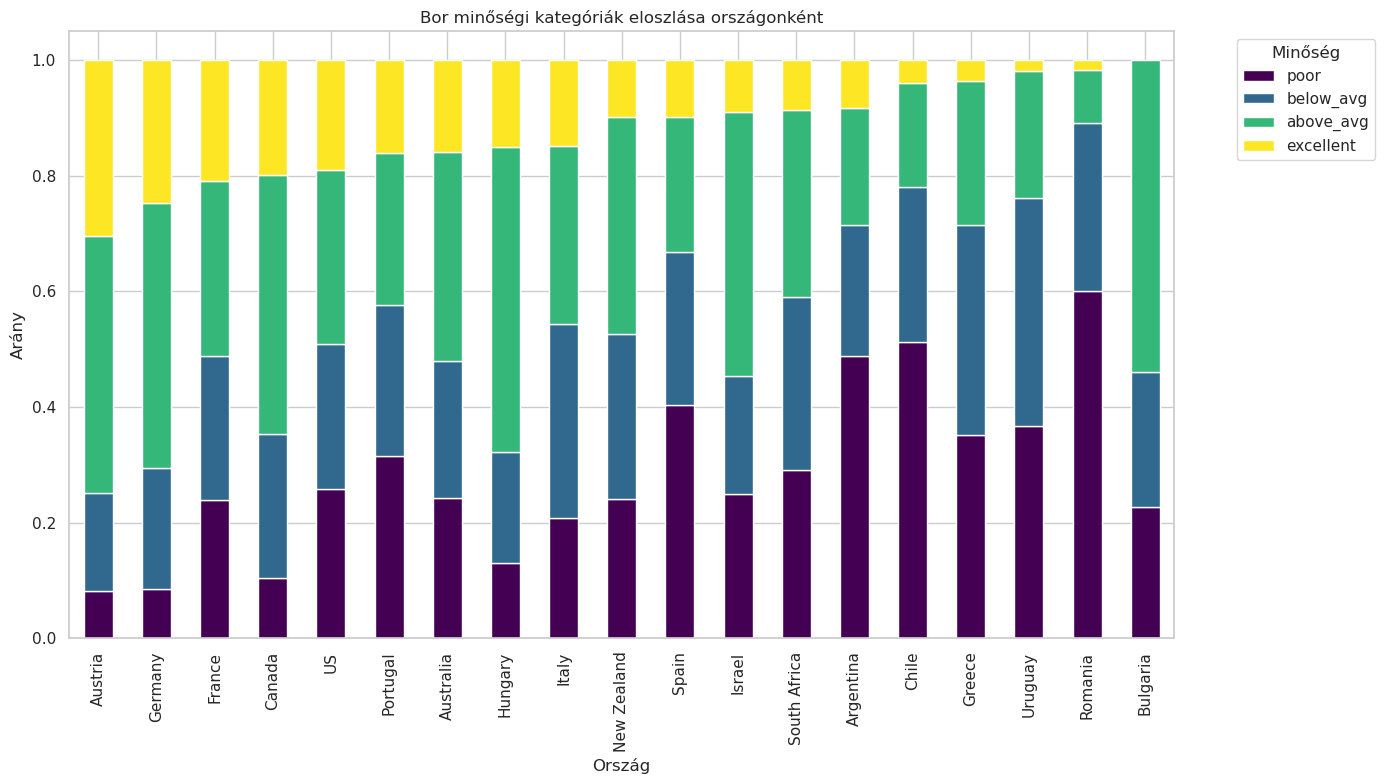

In [ ]:
# Minőségi kategóriák eloszlása országonként
# Ez megmutatja, hogy egy adott országból származó bor mekkora eséllyel esik egy bizonyos minőségi kategóriába

# Kereszttábla készítése és normalizálása (százalékos eloszlás)
ct = pd.crosstab(df_filtered_country['country'], df_filtered_country['group'], normalize='index')

# Rendezés: azon országok kerüljenek előre, ahol a legnagyobb az "excellent" borok aránya
ct = ct.reindex(ct.sort_values(by='excellent', ascending=False).index)

# Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Bor minőségi kategóriák eloszlása országonként')
plt.ylabel('Arány')
plt.xlabel('Ország')
plt.legend(title='Minőség', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_40309/1589726892.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="coolwarm")


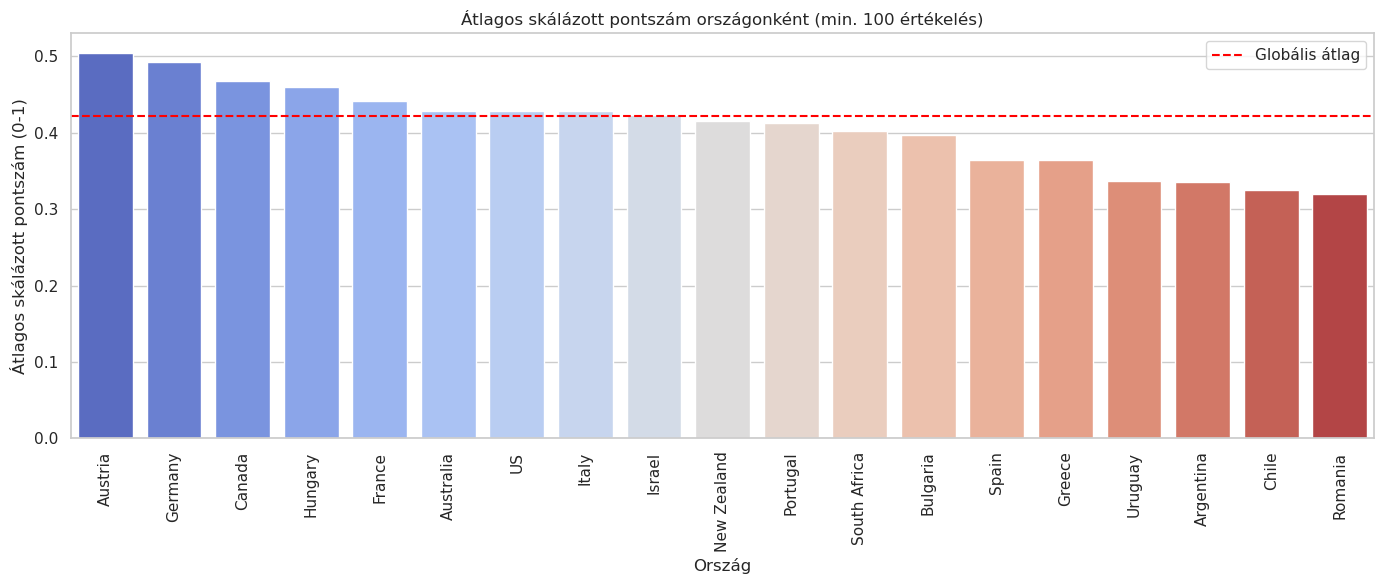

Top 5 ország átlagos pontszám szerint:
country
Austria    0.505067
Germany    0.492587
Canada     0.468482
Hungary    0.459589
France     0.442255
Name: points_scaled, dtype: float64

Bottom 5 ország átlagos pontszám szerint:
country
Greece       0.364163
Uruguay      0.337615
Argentina    0.335513
Chile        0.324676
Romania      0.320000
Name: points_scaled, dtype: float64


In [ ]:
# Átlagos pontszám országonként

# Használjuk a skálázott pontszámot
country_avg_points = df_filtered_country.groupby('country')['points_scaled'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.title('Átlagos skálázott pontszám országonként (min. 100 értékelés)')
plt.ylabel('Átlagos skálázott pontszám (0-1)')
plt.xlabel('Ország')
plt.axhline(y=df_filtered_country['points_scaled'].mean(), color='red', linestyle='--', label='Globális átlag')
plt.legend()
plt.tight_layout()
plt.show()

# Top 5 és Bottom 5 ország átlagpontszáma
print("Top 5 ország átlagos pontszám szerint:")
print(country_avg_points.head())
print("\nBottom 5 ország átlagos pontszám szerint:")
print(country_avg_points.tail())

/tmp/ipykernel_40309/1877320629.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='keyword', y='avg_points', data=df_keywords, palette="RdYlGn")


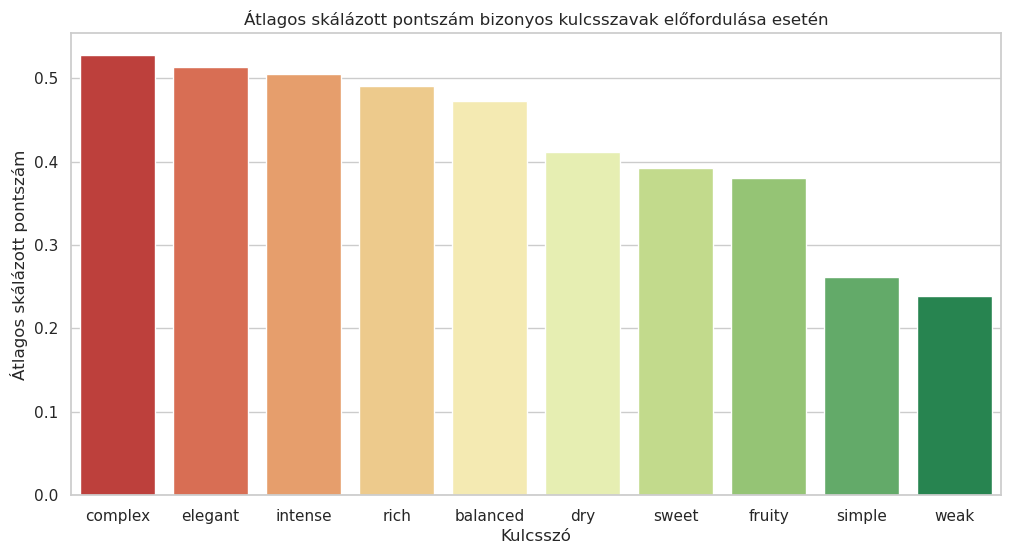

,keyword,avg_points,count
1,complex,0.527385,8269
2,elegant,0.513428,5682
9,intense,0.504547,4805
3,rich,0.490176,22710
7,balanced,0.472256,8582
5,dry,0.410996,18484
6,sweet,0.392012,15730
4,fruity,0.380026,9455
0,simple,0.261433,3831
8,weak,0.239085,142


In [ ]:
# Kulcsszavak keresése a leírásban (Szövegbányászat alapok)
# Mivel a 'description' mező szöveges, keressünk benne olyan szavakat, amik utalhatnak a minőségre.

keywords = ['simple', 'complex', 'elegant', 'rich', 'fruity', 'dry', 'sweet', 'balanced', 'weak', 'intense']
keyword_stats = []

for word in keywords:
    # Megnézzük azokat a sorokat, ahol szerepel a szó (kis/nagybetű nem számít)
    mask = df_categorized['description'].str.contains(word, case=False, na=False)
    if mask.sum() > 0:
        # Skálázott pontszámot használunk
        avg_score = df_categorized.loc[mask, 'points_scaled'].mean()
        count = mask.sum()
        keyword_stats.append({'keyword': word, 'avg_points': avg_score, 'count': count})

df_keywords = pd.DataFrame(keyword_stats).sort_values(by='avg_points', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='keyword', y='avg_points', data=df_keywords, palette="RdYlGn")
# plt.ylim(80, 95) # Eltávolítva, mert skálázott adatokat használunk
plt.title('Átlagos skálázott pontszám bizonyos kulcsszavak előfordulása esetén')
plt.ylabel('Átlagos skálázott pontszám')
plt.xlabel('Kulcsszó')
plt.show()

display(df_keywords)

/tmp/ipykernel_40309/3855095324.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='points', y='desc_length', data=df_categorized, palette="Blues")


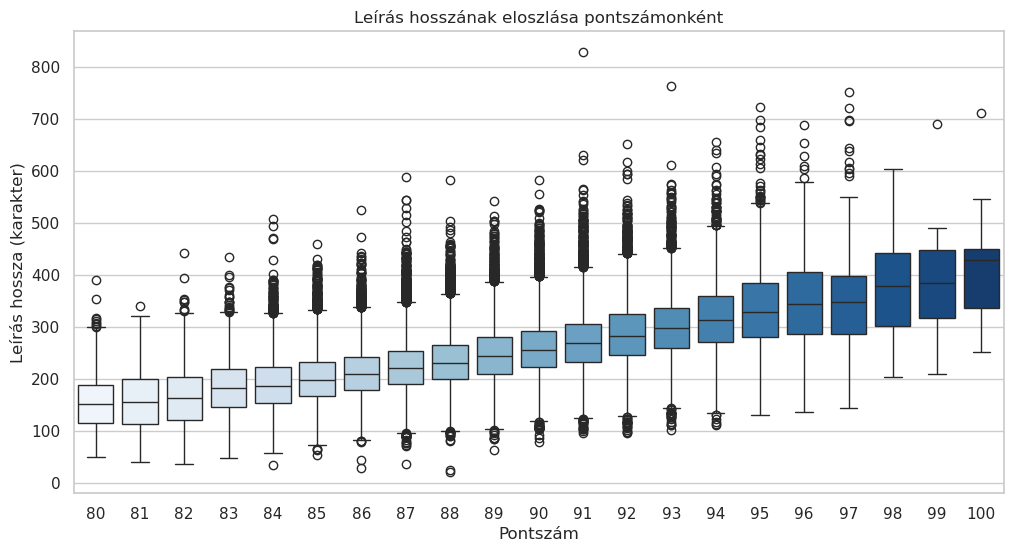

Korreláció a leírás hossza és a skálázott pontszám között: 0.56


In [ ]:
# Leírás hossza és a Pontszám kapcsolata

# Hossz kiszámítása
df_categorized['desc_length'] = df_categorized['description'].str.len()

plt.figure(figsize=(12, 6))
# Boxplot a pontszámok és a hossz összefüggésére
sns.boxplot(x='points', y='desc_length', data=df_categorized, palette="Blues")
plt.title('Leírás hosszának eloszlása pontszámonként')
plt.xlabel('Pontszám')
plt.ylabel('Leírás hossza (karakter)')
plt.show()

corr_len = df_categorized['desc_length'].corr(df_categorized['points_scaled'])
print(f"Korreláció a leírás hossza és a skálázott pontszám között: {corr_len:.2f}")

/tmp/ipykernel_40309/2771998020.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='positive_words', y='points_scaled', data=df_categorized[df_categorized['positive_words'] <= 5],
/tmp/ipykernel_40309/2771998020.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sentiment_score', y='points_scaled',


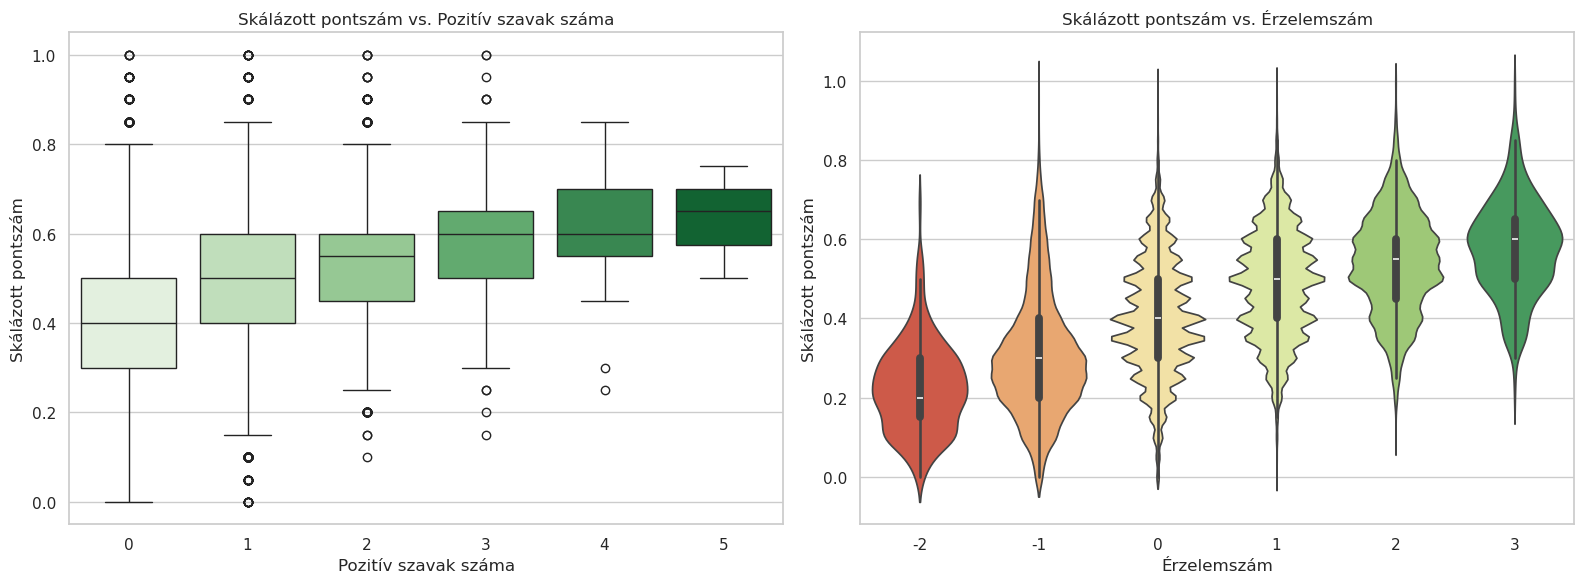

Korreláció pozitív szavak és skálázott pontszám között: 0.321
Korreláció érzelemszám és skálázott pontszám között: 0.363


In [ ]:
# Leírásban szereplő pozitív és negatív szavak hatása

positive_words = ['excellent', 'exceptional', 'outstanding', 'superb', 'remarkable', 
                  'complex', 'elegant', 'rich', 'balanced', 'harmonious', 'refined']
negative_words = ['simple', 'basic', 'ordinary', 'weak', 'thin', 'harsh', 
                  'flat', 'dull', 'coarse', 'unbalanced']

def count_keywords(text, word_list):
    """Megszámolja, hány kulcsszó szerepel a szövegben"""
    if pd.isna(text):
        return 0
    text_lower = text.lower()
    return sum(1 for word in word_list if word in text_lower)

df_categorized['positive_words'] = df_categorized['description'].apply(lambda x: count_keywords(x, positive_words))
df_categorized['negative_words'] = df_categorized['description'].apply(lambda x: count_keywords(x, negative_words))
df_categorized['sentiment_score'] = df_categorized['positive_words'] - df_categorized['negative_words']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pozitív szavak vs pontszám (skálázott)
sns.boxplot(x='positive_words', y='points_scaled', data=df_categorized[df_categorized['positive_words'] <= 5], 
            ax=axes[0], palette="Greens")
axes[0].set_title('Skálázott pontszám vs. Pozitív szavak száma')
axes[0].set_xlabel('Pozitív szavak száma')
axes[0].set_ylabel('Skálázott pontszám')

# Sentiment score vs pontszám (skálázott)
sns.violinplot(x='sentiment_score', y='points_scaled', 
               data=df_categorized[(df_categorized['sentiment_score'] >= -2) & (df_categorized['sentiment_score'] <= 3)],
               ax=axes[1], palette="RdYlGn")
axes[1].set_title('Skálázott pontszám vs. Érzelemszám')
axes[1].set_xlabel('Érzelemszám')
axes[1].set_ylabel('Skálázott pontszám')

plt.tight_layout()
plt.show()

# Korreláció
print(f"Korreláció pozitív szavak és skálázott pontszám között: {df_categorized['positive_words'].corr(df_categorized['points_scaled']):.3f}")
print(f"Korreláció érzelemszám és skálázott pontszám között: {df_categorized['sentiment_score'].corr(df_categorized['points_scaled']):.3f}")

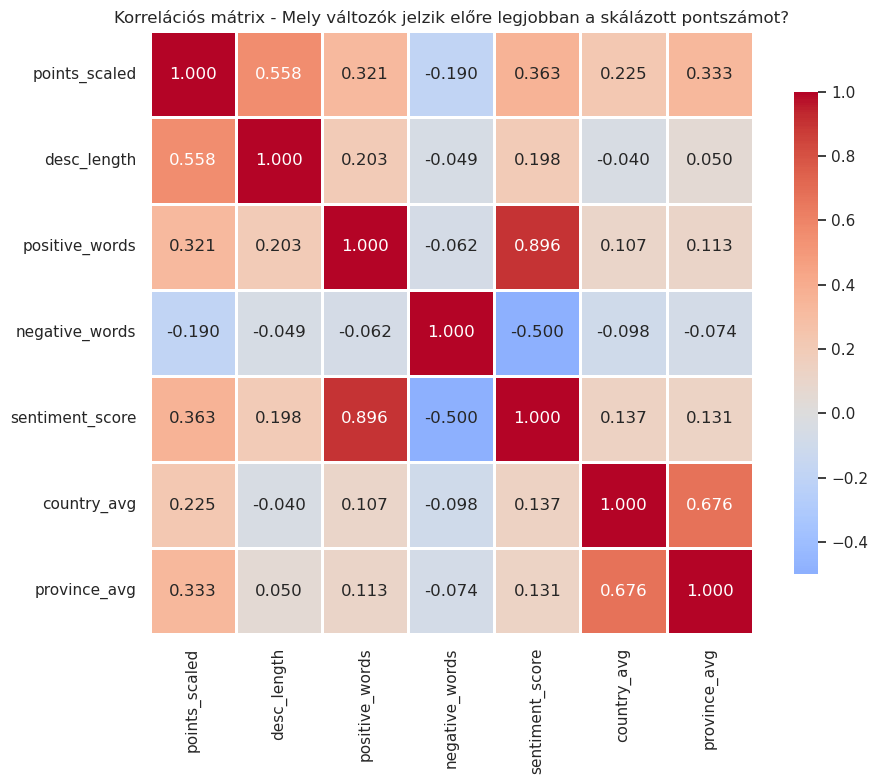


Korreláció a skálázott pontszámmal:
points_scaled      1.000000
desc_length        0.557760
sentiment_score    0.363414
province_avg       0.333382
positive_words     0.321226
country_avg        0.225251
negative_words    -0.189929
Name: points_scaled, dtype: float64


In [ ]:
# Predikciós erő összefoglalása - Korrelációs mátrix

# Létrehozunk néhány aggregált változót ország és tartomány szintjén (skálázott pontszám alapján)
country_avg_map = df_categorized.groupby('country')['points_scaled'].transform('mean')
province_avg_map = df_categorized.groupby('province')['points_scaled'].transform('mean')

correlation_df = pd.DataFrame({
    'points_scaled': df_categorized['points_scaled'],
    'desc_length': df_categorized['desc_length'],
    'positive_words': df_categorized['positive_words'],
    'negative_words': df_categorized['negative_words'],
    'sentiment_score': df_categorized['sentiment_score'],
    'country_avg': country_avg_map,
    'province_avg': province_avg_map
})

# Korreláció számítás
corr_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Korrelációs mátrix - Mely változók jelzik előre legjobban a skálázott pontszámot?')
plt.tight_layout()
plt.show()

print("\nKorreláció a skálázott pontszámmal:")
print(corr_matrix['points_scaled'].sort_values(ascending=False))

/tmp/ipykernel_40309/288288538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=combo_avg.index, x=combo_avg.values, palette="rocket", orient='h')


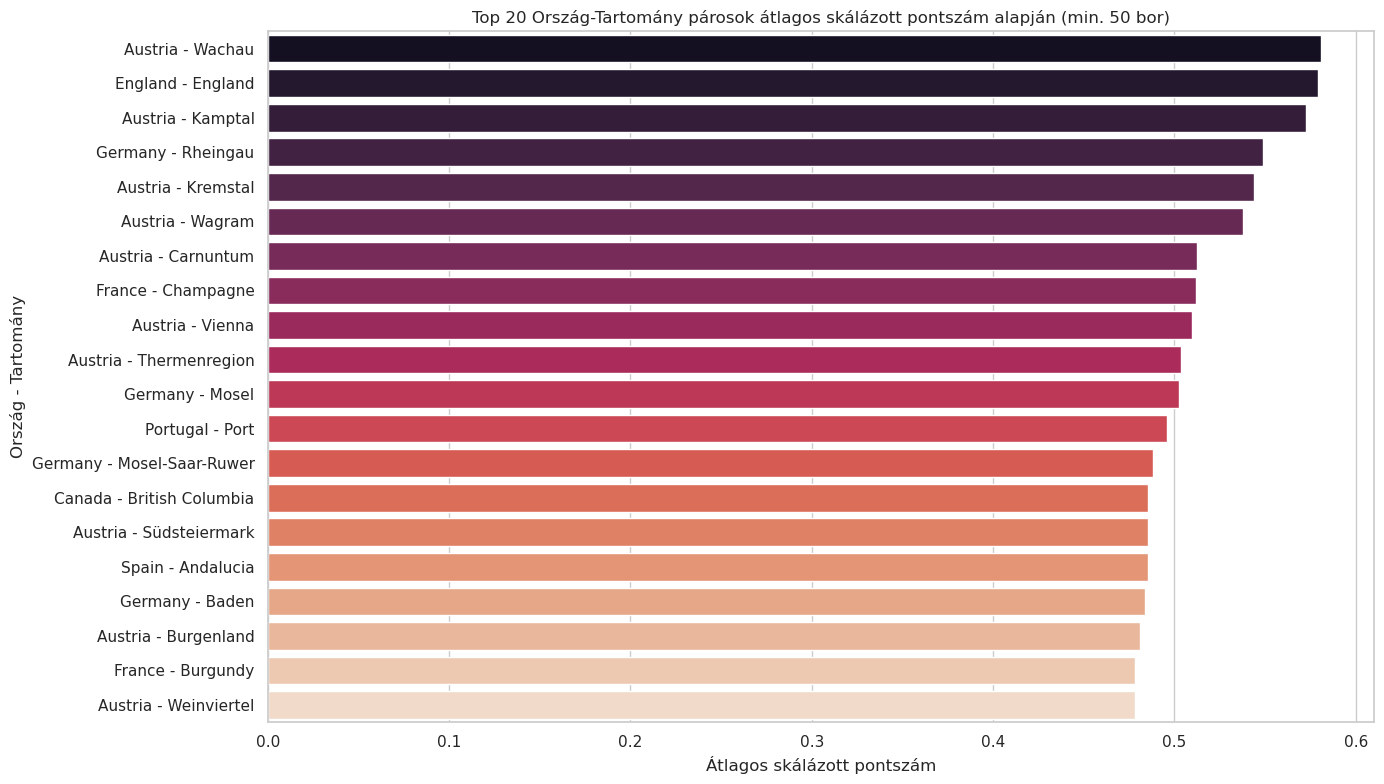

In [ ]:
# Kombinált terület elemzés: Ország + Tartomány

# Kombinált oszlop létrehozása
df_categorized['country_province'] = df_categorized['country'] + ' - ' + df_categorized['province']

# Szűrés: csak ahol legalább 50 bor van
combo_counts = df_categorized['country_province'].value_counts()
valid_combos = combo_counts[combo_counts >= 50].index
df_combo = df_categorized[df_categorized['country_province'].isin(valid_combos)]

# Skálázott pontszám használata
combo_avg = df_combo.groupby('country_province')['points_scaled'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(y=combo_avg.index, x=combo_avg.values, palette="rocket", orient='h')
plt.title('Top 20 Ország-Tartomány párosok átlagos skálázott pontszám alapján (min. 50 bor)')
plt.xlabel('Átlagos skálázott pontszám')
plt.ylabel('Ország - Tartomány')
plt.tight_layout()
plt.show()

Egyedi region_1 értékek száma: 1230
Hiányzó region_1 értékek: 0


/tmp/ipykernel_40309/3178350268.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index, y=region_avg.values, palette="magma")


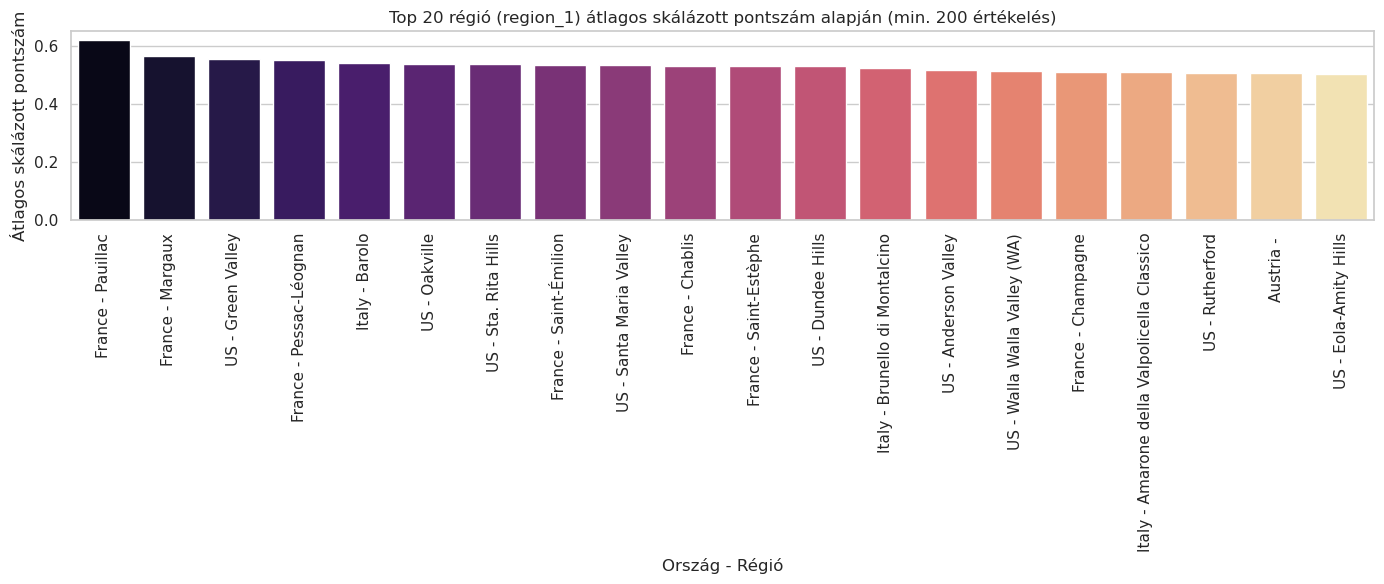

In [ ]:
# Régiók (region_1) elemzése

# Kombinált oszlop létrehozása a megjelenítéshez: Ország - Régió
df_categorized['country_region'] = df_categorized['country'] + ' - ' + df_categorized['region_1']

# Megnézzük, hány egyedi régió van
print(f"Egyedi region_1 értékek száma: {df_categorized['region_1'].nunique()}")
print(f"Hiányzó region_1 értékek: {df_categorized['region_1'].isna().sum()}")

# Top régiók, ahol van elég adat
region_counts = df_categorized['country_region'].value_counts()
top_regions = region_counts[region_counts > 200].index
df_top_regions = df_categorized[df_categorized['country_region'].isin(top_regions)]

# Skálázott pontszám használata
region_avg = df_top_regions.groupby('country_region')['points_scaled'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=region_avg.index, y=region_avg.values, palette="magma")
plt.xticks(rotation=90)
plt.title('Top 20 régió (region_1) átlagos skálázott pontszám alapján (min. 200 értékelés)')
plt.ylabel('Átlagos skálázott pontszám')
plt.xlabel('Ország - Régió')
plt.tight_layout()
plt.show()

/tmp/ipykernel_40309/3620526093.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


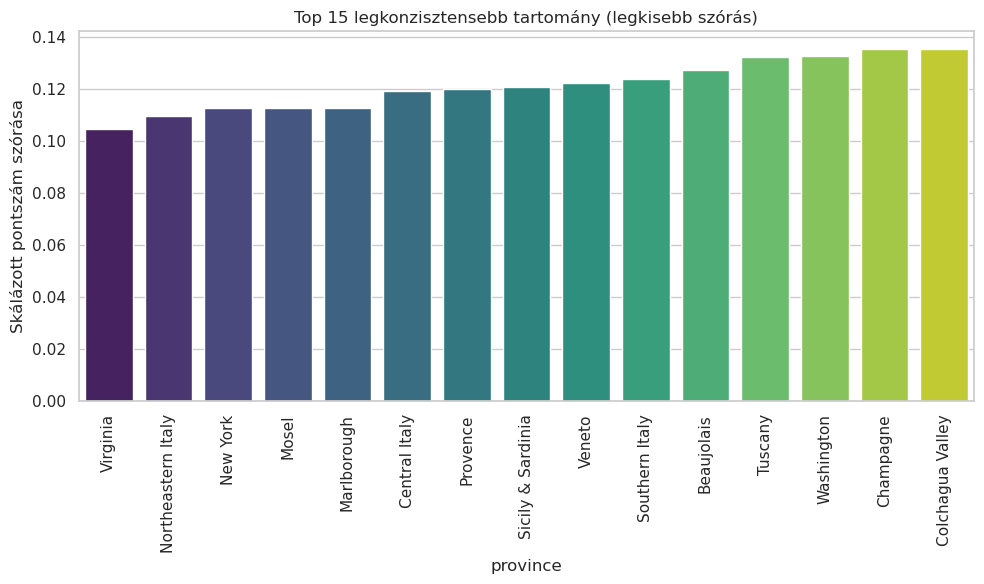

In [83]:
# Tartomány (Province) – csak a konzisztencia plot

top_provinces = df_categorized['province'].value_counts().head(30).index
df_top_provinces = df_categorized[df_categorized['province'].isin(top_provinces)]

# Skálázott pontszám használata
province_stats = df_top_provinces.groupby('province')['points_scaled'].agg(['mean', 'std', 'count'])

# Szórás szerinti rendezés
province_stats_sorted = province_stats.sort_values(by='std')

plt.figure(figsize=(10, 6))

sns.barplot(
    x=province_stats_sorted.head(15).index,
    y=province_stats_sorted.head(15)['std'],
    palette="viridis"
)

plt.xticks(rotation=90)
plt.title('Top 15 legkonzisztensebb tartomány (legkisebb szórás)')
plt.ylabel('Skálázott pontszám szórása')

plt.tight_layout()
plt.show()

In [81]:
print("Top 10 tartomány átlag és konzisztencia alapján:")
display(province_stats.head(10))

Top 10 tartomány átlag és konzisztencia alapján:


,mean,std,count
province,,,
Alentejano,0.395251,0.135662,937
Alsace,0.468607,0.148265,2440
Beaujolais,0.397749,0.127338,1044
Bordeaux,0.432949,0.162616,5941
Burgundy,0.478467,0.155505,3980
California,0.431389,0.162701,36247
Catalonia,0.372637,0.142258,1164
Central Italy,0.369586,0.119232,1233
Champagne,0.511748,0.135106,1613
